In [47]:
from datasets import load_dataset
import pandas as pd


In [48]:
# Load the dataset
dataset = load_dataset("fka/awesome-chatgpt-prompts")


In [49]:
df = pd.DataFrame(dataset["train"])


In [50]:
# Show first 5 rows
df.head()


,act,prompt,for_devs,type,contributor
0,Ethereum Developer,Imagine you are an experienced Ethereum develo...,True,TEXT,ameya-2003
1,Linux Terminal,I want you to act as a linux terminal. I will ...,True,TEXT,f
2,English Translator and Improver,"I want you to act as an English translator, sp...",False,TEXT,f
3,Job Interviewer,I want you to act as an interviewer. I will be...,False,TEXT,"f,iltekin"
4,JavaScript Console,I want you to act as a javascript console. I w...,True,TEXT,omerimzali


In [51]:
# Dataset shape
df.shape


(1745, 5)

In [52]:
# Column names
df.columns


Index(['act', 'prompt', 'for_devs', 'type', 'contributor'], dtype='object')

In [53]:
# General info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1745 entries, 0 to 1744
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   act          1745 non-null   object
 1   prompt       1745 non-null   object
 2   for_devs     1745 non-null   bool  
 3   type         1745 non-null   object
 4   contributor  1745 non-null   object
dtypes: bool(1), object(4)
memory usage: 56.4+ KB


In [54]:
# Length of each prompt
df["prompt_length"] = df["prompt"].apply(len)

# Basic statistics
df["prompt_length"].describe()


,prompt_length
count,1745.000000
mean,2620.632092
std,6485.846701
min,29.000000
25%,552.000000
50%,947.000000
75%,2526.000000
max,144260.000000


In [55]:
# Top 10 most common personas
df["act"].value_counts().head(10)


,count
act,
Opus-Driven Deep Thinking System,1
Ethereum Developer,1
Linux Terminal,1
English Translator and Improver,1
Job Interviewer,1
JavaScript Console,1
Excel Sheet,1
English Pronunciation Helper,1
Spoken English Teacher and Improver,1


In [56]:
df.isnull().sum()


,0
act,0
prompt,0
for_devs,0
type,0
contributor,0
prompt_length,0


In [57]:
df = df.dropna(subset=["act", "prompt"])


In [58]:
df = df.drop_duplicates(subset="prompt")


In [59]:
#Strip extra spaces and clean text formatting
df["act"] = df["act"].str.strip()
df["prompt"] = df["prompt"].str.strip()


In [60]:
#Remove very short prompts (noise filtering)
df["prompt_length"] = df["prompt"].apply(len)

df = df[df["prompt_length"] > 50]


In [61]:
#lower case normalize
df["prompt_clean"] = df["prompt"].str.lower()


In [62]:
#remove whitespace
df["prompt_clean"] = df["prompt_clean"].str.replace(r"\s+", " ", regex=True)


In [63]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 1739 entries, 0 to 1744
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   act            1739 non-null   object
 1   prompt         1739 non-null   object
 2   for_devs       1739 non-null   bool  
 3   type           1739 non-null   object
 4   contributor    1739 non-null   object
 5   prompt_length  1739 non-null   int64 
 6   prompt_clean   1739 non-null   object
dtypes: bool(1), int64(1), object(5)
memory usage: 96.8+ KB


,act,prompt,for_devs,type,contributor,prompt_length,prompt_clean
0,Ethereum Developer,Imagine you are an experienced Ethereum develo...,True,TEXT,ameya-2003,578,imagine you are an experienced ethereum develo...
1,Linux Terminal,I want you to act as a linux terminal. I will ...,True,TEXT,f,426,i want you to act as a linux terminal. i will ...
2,English Translator and Improver,"I want you to act as an English translator, sp...",False,TEXT,f,594,"i want you to act as an english translator, sp..."
3,Job Interviewer,I want you to act as an interviewer. I will be...,False,TEXT,"f,iltekin",468,i want you to act as an interviewer. i will be...
4,JavaScript Console,I want you to act as a javascript console. I w...,True,TEXT,omerimzali,464,i want you to act as a javascript console. i w...


In [64]:
#  Final cleaning + enforce schema

# Recompute lengths (in case earlier cells were re-run out of order)
df["prompt_length"] = df["prompt"].astype(str).apply(len)

# Remove very short prompts (noise filtering) - adjust threshold if needed
MIN_LEN = 30
df = df[df["prompt_length"] >= MIN_LEN].copy()

# Remove extreme long prompts (optional safety)
MAX_LEN = 2000
df = df[df["prompt_length"] <= MAX_LEN].copy()

# Ensure clean strings
df["act"] = df["act"].astype(str).str.strip()
df["prompt"] = df["prompt"].astype(str).str.strip()

# Rebuild prompt_clean robustly
df["prompt_clean"] = (
    df["prompt"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Drop empties after cleaning
df = df[(df["act"] != "") & (df["prompt_clean"] != "")].copy()

print("Final shape:", df.shape)
df.head(3)

Final shape: (1219, 7)


,act,prompt,for_devs,type,contributor,prompt_length,prompt_clean
0,Ethereum Developer,Imagine you are an experienced Ethereum develo...,True,TEXT,ameya-2003,578,imagine you are an experienced ethereum develo...
1,Linux Terminal,I want you to act as a linux terminal. I will ...,True,TEXT,f,426,i want you to act as a linux terminal. i will ...
2,English Translator and Improver,"I want you to act as an English translator, sp...",False,TEXT,f,594,"i want you to act as an english translator, sp..."


In [65]:
# ✅ Stable IDs + quick descriptive stats

df = df.reset_index(drop=True)
df["prompt_id"] = df.index.astype(int)

print("Unique personas (act):", df["act"].nunique())
print("Total prompts:", len(df))

print("\nTop 10 personas:")
display(df["act"].value_counts().head(10))

print("\nPrompt length summary:")
display(df["prompt_length"].describe())

Unique personas (act): 1219
Total prompts: 1219

Top 10 personas:


,count
act,
Opus-Driven Deep Thinking System,1
Ethereum Developer,1
Linux Terminal,1
High-End Technology-Inspired Website UI Redesign,1
RPA/Agentic AI Process Developer Portfolio Design for Claude,1
Modify Front-End Webpage with Codex and Image Input,1
Code Review Professional,1
Cyber-Pulse: 3D Neon Particle Swarm,1
Gravity Shift: Low-Poly Physics Platformer,1



Prompt length summary:


,prompt_length
count,1219.000000
mean,770.642330
std,448.851695
min,57.000000
25%,443.000000
50%,711.000000
75%,1010.500000
max,1992.000000


In [66]:
# ✅ Save outputs (Week 1 deliverable)

CLEAN_CSV = "prompt_library_cleaned.csv"
CLEAN_PARQUET = "prompt_library_cleaned.parquet"

df.to_csv(CLEAN_CSV, index=False)
df.to_parquet(CLEAN_PARQUET, index=False)

print("Saved:", CLEAN_CSV, "and", CLEAN_PARQUET)

Saved: prompt_library_cleaned.csv and prompt_library_cleaned.parquet


In [67]:
# ✅ Persona prompt wrapper (used in Week 2 experiment runner)

def build_persona_prompt(act: str, user_query: str) -> str:
    """
    Returns a persona-conditioned prompt format.
    Keep it consistent so comparisons are fair.
    """
    act = str(act).strip()
    user_query = str(user_query).strip()
    return (
        f"You are acting as: {act}.\n"
        f"Follow the persona style, but do not invent facts.\n\n"
        f"User query:\n{user_query}\n\n"
        f"Answer:"
    )

# Quick demo
demo_act = df.loc[0, "act"]
demo_query = "Explain what overfitting means in machine learning in 2 sentences."
print(build_persona_prompt(demo_act, demo_query)[:400], "...")

You are acting as: Ethereum Developer.
Follow the persona style, but do not invent facts.

User query:
Explain what overfitting means in machine learning in 2 sentences.

Answer: ...


In [68]:
import json

# ✅ Task suite with ground truth (Week 1 baseline artifact)

task_suite = [
    {
        "task_id": "math_exact_1",
        "task_type": "exact_match",
        "query": "What is 17 + 25? Reply with only the number.",
        "ground_truth": "42"
    },
    {
        "task_id": "math_exact_2",
        "task_type": "exact_match",
        "query": "What is 12 * 8? Reply with only the number.",
        "ground_truth": "96"
    },
    {
        "task_id": "extract_email_1",
        "task_type": "exact_match",
        "query": "Extract the email address from: 'Contact me at ali.khan99@gmail.com for details.' Reply with only the email.",
        "ground_truth": "ali.khan99@gmail.com"
    },
    {
        "task_id": "json_format_1",
        "task_type": "json_validity",
        "query": "Return ONLY valid JSON with keys: name, age. Use name='Sara' and age=21.",
        "ground_truth": {"name": "Sara", "age": 21}
    }
]

TASK_JSON = "week1_task_suite.json"
with open(TASK_JSON, "w", encoding="utf-8") as f:
    json.dump(task_suite, f, ensure_ascii=False, indent=2)

print("Saved:", TASK_JSON)
task_suite

Saved: week1_task_suite.json


[{'task_id': 'math_exact_1',
  'task_type': 'exact_match',
  'query': 'What is 17 + 25? Reply with only the number.',
  'ground_truth': '42'},
 {'task_id': 'math_exact_2',
  'task_type': 'exact_match',
  'query': 'What is 12 * 8? Reply with only the number.',
  'ground_truth': '96'},
 {'task_id': 'extract_email_1',
  'task_type': 'exact_match',
  'query': "Extract the email address from: 'Contact me at ali.khan99@gmail.com for details.' Reply with only the email.",
  'ground_truth': 'ali.khan99@gmail.com'},
 {'task_id': 'json_format_1',
  'task_type': 'json_validity',
  'query': "Return ONLY valid JSON with keys: name, age. Use name='Sara' and age=21.",
  'ground_truth': {'name': 'Sara', 'age': 21}}]

In [69]:
# ✅ Evaluation utilities (Week 1 deliverable)

def normalize_text(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def exact_match(pred: str, truth: str) -> int:
    return int(normalize_text(pred) == normalize_text(truth))

def is_valid_json(text: str) -> int:
    try:
        json.loads(text)
        return 1
    except Exception:
        return 0

def similarity(a: str, b: str) -> float:
    # Simple string similarity for consistency (Week 1 baseline)
    a, b = normalize_text(a), normalize_text(b)
    return SequenceMatcher(None, a, b).ratio()

print("✓ Evaluation utilities ready")

✓ Evaluation utilities ready


In [70]:
# ✅ Dry-run checks (should run with no errors)
import re
from difflib import SequenceMatcher
# Exact match example
print("Exact match test:", exact_match("42", "42"), exact_match(" 42 ", "42"), exact_match("43", "42"))

# JSON validity example
good_json = '{"name":"Sara","age":21}'
bad_json = '{"name":"Sara","age":21'
print("JSON validity test:", is_valid_json(good_json), is_valid_json(bad_json))

# Consistency similarity example
print("Similarity test:", similarity("Hello World", "hello   world"), similarity("Answer is 42", "Answer is 43"))

Exact match test: 1 1 0
JSON validity test: 1 0
Similarity test: 1.0 0.9166666666666666


**Week 3 working**

In [71]:
# Verify dataset structure and persona distribution

print("Dataset shape:", df.shape)

print("\nUnique personas:", df["act"].nunique())

print("\nTop personas:")
display(df["act"].value_counts().head(20))

print("\nPrompt length statistics:")
display(df["prompt_length"].describe())

Dataset shape: (1219, 8)

Unique personas: 1219

Top personas:


,count
act,
Opus-Driven Deep Thinking System,1
Ethereum Developer,1
Linux Terminal,1
High-End Technology-Inspired Website UI Redesign,1
RPA/Agentic AI Process Developer Portfolio Design for Claude,1
Modify Front-End Webpage with Codex and Image Input,1
Code Review Professional,1
Cyber-Pulse: 3D Neon Particle Swarm,1
Gravity Shift: Low-Poly Physics Platformer,1



Prompt length statistics:


,prompt_length
count,1219.000000
mean,770.642330
std,448.851695
min,57.000000
25%,443.000000
50%,711.000000
75%,1010.500000
max,1992.000000


In [72]:
# STEP 2 — Expanded evaluation task suite

task_suite = [
    {
        "task_id": "math_1",
        "task_type": "exact_match",
        "query": "What is 24 + 18? Reply with only the number.",
        "ground_truth": "42"
    },
    {
        "task_id": "math_2",
        "task_type": "exact_match",
        "query": "What is 7 * 9? Reply with only the number.",
        "ground_truth": "63"
    },
    {
        "task_id": "capital_1",
        "task_type": "exact_match",
        "query": "What is the capital city of France? Reply with only the city name.",
        "ground_truth": "Paris"
    },
    {
        "task_id": "capital_2",
        "task_type": "exact_match",
        "query": "What is the capital of Pakistan?",
        "ground_truth": "Islamabad"
    },
    {
        "task_id": "classification_1",
        "task_type": "exact_match",
        "query": "Classify this text as Positive or Negative sentiment: 'The movie was fantastic and enjoyable.'",
        "ground_truth": "Positive"
    },
    {
        "task_id": "classification_2",
        "task_type": "exact_match",
        "query": "Classify this text as Positive or Negative sentiment: 'The service was terrible and disappointing.'",
        "ground_truth": "Negative"
    },
    {
        "task_id": "json_task",
        "task_type": "json_validity",
        "query": "Return ONLY valid JSON with keys name and age. name='Ali', age=25",
        "ground_truth": {"name": "Ali", "age": 25}
    }
]

print("Total tasks:", len(task_suite))
task_suite

Total tasks: 7


[{'task_id': 'math_1',
  'task_type': 'exact_match',
  'query': 'What is 24 + 18? Reply with only the number.',
  'ground_truth': '42'},
 {'task_id': 'math_2',
  'task_type': 'exact_match',
  'query': 'What is 7 * 9? Reply with only the number.',
  'ground_truth': '63'},
 {'task_id': 'capital_1',
  'task_type': 'exact_match',
  'query': 'What is the capital city of France? Reply with only the city name.',
  'ground_truth': 'Paris'},
 {'task_id': 'capital_2',
  'task_type': 'exact_match',
  'query': 'What is the capital of Pakistan?',
  'ground_truth': 'Islamabad'},
 {'task_id': 'classification_1',
  'task_type': 'exact_match',
  'query': "Classify this text as Positive or Negative sentiment: 'The movie was fantastic and enjoyable.'",
  'ground_truth': 'Positive'},
 {'task_id': 'classification_2',
  'task_type': 'exact_match',
  'query': "Classify this text as Positive or Negative sentiment: 'The service was terrible and disappointing.'",
  'ground_truth': 'Negative'},
 {'task_id': 'jso

In [73]:
# STEP 3 — Evaluation metrics wrapper

def evaluate_response(pred, truth, task_type):

    if task_type == "exact_match":
        return exact_match(pred, truth)

    if task_type == "json_validity":
        return is_valid_json(pred)

    return None

In [74]:
# STEP 4 — Load language model

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model loaded:", MODEL_NAME)
print("Device:", device)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded: google/flan-t5-small
Device: cuda


In [75]:
# STEP 5 — Model inference pipeline

def generate_response(prompt, max_tokens=128, temperature=0.7):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=True,
        temperature=temperature
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response.strip()

In [76]:
# STEP 6 — Prompt condition builders

def generic_prompt(query):
    return query


def persona_prompt(query, act):
    return f"""
You are acting as: {act}.
Answer the question clearly and accurately.

Question:
{query}

Answer:
""".strip()

In [77]:
# STEP 7 — Generate multiple runs per prompt

N_RUNS = 5

def run_prompt(prompt):

    responses = []

    for i in range(N_RUNS):
        resp = generate_response(prompt)
        responses.append(resp)

    return responses

In [78]:
# STEP 8 — Run experiment and store responses

results = []

sample_persona = df["act"].iloc[0]

for task in task_suite:

    query = task["query"]

    # Generic
    generic_runs = run_prompt(generic_prompt(query))

    for r in generic_runs:
        results.append({
            "task_id": task["task_id"],
            "condition": "generic",
            "response": r
        })

    # Persona
    persona_runs = run_prompt(persona_prompt(query, sample_persona))

    for r in persona_runs:
        results.append({
            "task_id": task["task_id"],
            "condition": "persona",
            "response": r
        })

results_df = pd.DataFrame(results)

print("Total responses collected:", len(results_df))
results_df.head()

Total responses collected: 70


,task_id,condition,response
0,math_1,generic,the day prior hastibened (tha). It has seen th...
1,math_1,generic,80914477285441295172944? How may
2,math_1,generic,72.00 2852948754596257646566473475659 84688053...
3,math_1,generic,15 + 15 will nods = 28 = 31 eight is 22 of it ...
4,math_1,generic,54 018 0602


In [79]:
# STEP 9 — Score model responses

scores = []

for i, row in results_df.iterrows():

    task = next(t for t in task_suite if t["task_id"] == row["task_id"])

    score = evaluate_response(
        row["response"],
        task["ground_truth"],
        task["task_type"]
    )

    scores.append(score)

results_df["score"] = scores

results_df.head()

,task_id,condition,response,score
0,math_1,generic,the day prior hastibened (tha). It has seen th...,0
1,math_1,generic,80914477285441295172944? How may,0
2,math_1,generic,72.00 2852948754596257646566473475659 84688053...,0
3,math_1,generic,15 + 15 will nods = 28 = 31 eight is 22 of it ...,0
4,math_1,generic,54 018 0602,0


In [80]:
import numpy as np
# STEP 10 — Compute performance metrics

accuracy_table = results_df.groupby("condition")["score"].mean()

print("Average Accuracy:")
display(accuracy_table)


# Consistency measurement (pairwise similarity)

consistency_scores = []

for task_id in results_df["task_id"].unique():

    subset = results_df[results_df["task_id"] == task_id]

    for cond in ["generic", "persona"]:

        outputs = subset[subset["condition"] == cond]["response"].tolist()

        sims = []

        for i in range(len(outputs)):
            for j in range(i+1, len(outputs)):
                sims.append(similarity(outputs[i], outputs[j]))

        if sims:
            consistency_scores.append({
                "task_id": task_id,
                "condition": cond,
                "consistency": np.mean(sims)
            })

consistency_df = pd.DataFrame(consistency_scores)

print("\nConsistency Scores:")
display(consistency_df)

Average Accuracy:


,score
condition,
generic,0.028571
persona,0.000000



Consistency Scores:


,task_id,condition,consistency
0,math_1,generic,0.105833
1,math_1,persona,0.065119
2,math_2,generic,0.121749
3,math_2,persona,0.110688
4,capital_1,generic,0.203781
5,capital_1,persona,0.071297
6,capital_2,generic,0.128074
7,capital_2,persona,0.159140
8,classification_1,generic,0.107459
9,classification_1,persona,0.088741


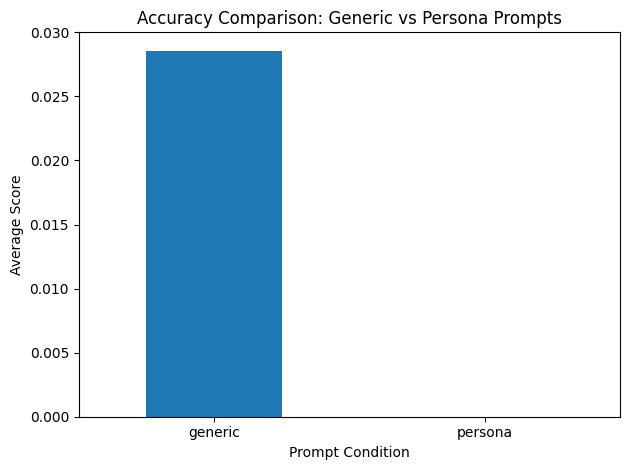

In [81]:
# STEP 11 — Accuracy comparison plot

import matplotlib.pyplot as plt

plt.figure()

accuracy_table.plot(kind="bar")

plt.title("Accuracy Comparison: Generic vs Persona Prompts")
plt.ylabel("Average Score")
plt.xlabel("Prompt Condition")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

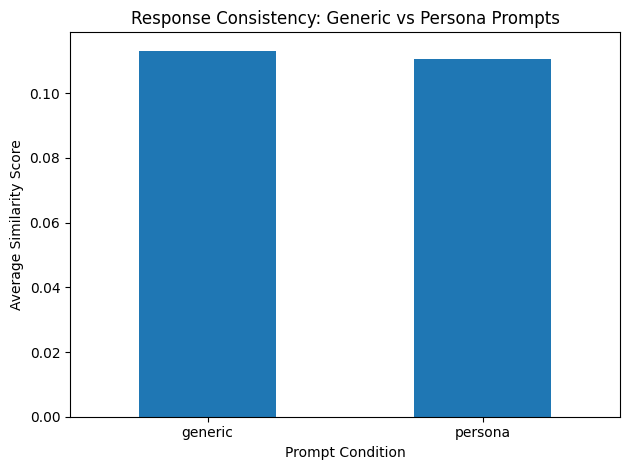

In [82]:
# STEP 12 — Consistency comparison plot

consistency_summary = consistency_df.groupby("condition")["consistency"].mean()

plt.figure()

consistency_summary.plot(kind="bar")

plt.title("Response Consistency: Generic vs Persona Prompts")
plt.ylabel("Average Similarity Score")
plt.xlabel("Prompt Condition")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [83]:
# STEP 13 — Save results for report analysis

RESULTS_FILE = "prompt_experiment_results.csv"
CONSISTENCY_FILE = "consistency_results.csv"

results_df.to_csv(RESULTS_FILE, index=False)
consistency_df.to_csv(CONSISTENCY_FILE, index=False)

print("Saved experiment outputs:")
print("-", RESULTS_FILE)
print("-", CONSISTENCY_FILE)

Saved experiment outputs:
- prompt_experiment_results.csv
- consistency_results.csv


In [84]:
# STEP 14 — Load second model (Flan-T5 Base)

MODEL_NAME_2 = "google/flan-t5-base"

tokenizer_2 = AutoTokenizer.from_pretrained(MODEL_NAME_2)
model_2 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME_2)

model_2.to(device)

print("Second model loaded:", MODEL_NAME_2)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Second model loaded: google/flan-t5-base


In [85]:
# STEP 15 — Generalized inference function

def generate_response_model(prompt, model, tokenizer, max_tokens=128, temperature=0.7):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=True,
        temperature=temperature
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return response.strip()

In [86]:
# STEP 16 — Multi-model run function

def run_prompt_model(prompt, model, tokenizer):

    responses = []

    for i in range(N_RUNS):
        resp = generate_response_model(prompt, model, tokenizer)
        responses.append(resp)

    return responses

In [87]:
# STEP 17 — Run experiments for both models

results_multi = []

models = [
    ("flan_small", model, tokenizer),
    ("flan_base", model_2, tokenizer_2)
]

sample_persona = df["act"].iloc[0]

for model_name, mdl, tok in models:

    for task in task_suite:

        query = task["query"]

        # Generic
        generic_runs = run_prompt_model(generic_prompt(query), mdl, tok)

        for r in generic_runs:
            results_multi.append({
                "model": model_name,
                "task_id": task["task_id"],
                "condition": "generic",
                "response": r
            })

        # Persona
        persona_runs = run_prompt_model(persona_prompt(query, sample_persona), mdl, tok)

        for r in persona_runs:
            results_multi.append({
                "model": model_name,
                "task_id": task["task_id"],
                "condition": "persona",
                "response": r
            })

results_multi_df = pd.DataFrame(results_multi)

print("Total responses:", len(results_multi_df))
results_multi_df.head()

Total responses: 140


,model,task_id,condition,response
0,flan_small,math_1,generic,"16 for 9/54 or t8 per game 4 please change! ,s..."
1,flan_small,math_1,generic,456063
2,flan_small,math_1,generic,26th is less as 17 hours of daily walk; just a...
3,flan_small,math_1,generic,call back 24
4,flan_small,math_1,generic,"18 years, 60s. Yes my brother calls me tonight..."


In [88]:
# STEP 18 — Evaluate multi-model results

scores = []

for i, row in results_multi_df.iterrows():

    task = next(t for t in task_suite if t["task_id"] == row["task_id"])

    score = evaluate_response(
        row["response"],
        task["ground_truth"],
        task["task_type"]
    )

    scores.append(score)

results_multi_df["score"] = scores

results_multi_df.head()

,model,task_id,condition,response,score
0,flan_small,math_1,generic,"16 for 9/54 or t8 per game 4 please change! ,s...",0
1,flan_small,math_1,generic,456063,0
2,flan_small,math_1,generic,26th is less as 17 hours of daily walk; just a...,0
3,flan_small,math_1,generic,call back 24,0
4,flan_small,math_1,generic,"18 years, 60s. Yes my brother calls me tonight...",0


In [89]:
# STEP 19 — Accuracy comparison across models

accuracy_multi = results_multi_df.groupby(["model", "condition"])["score"].mean().unstack()

print("Accuracy Table:")
display(accuracy_multi)

Accuracy Table:


condition,generic,persona
model,,
flan_base,0.0,0.0
flan_small,0.0,0.0


In [90]:
# STEP 20 — Consistency per model

consistency_multi = []

for model_name in results_multi_df["model"].unique():

    for task_id in results_multi_df["task_id"].unique():

        subset = results_multi_df[
            (results_multi_df["model"] == model_name) &
            (results_multi_df["task_id"] == task_id)
        ]

        for cond in ["generic", "persona"]:

            outputs = subset[subset["condition"] == cond]["response"].tolist()

            sims = []

            for i in range(len(outputs)):
                for j in range(i+1, len(outputs)):
                    sims.append(similarity(outputs[i], outputs[j]))

            if sims:
                consistency_multi.append({
                    "model": model_name,
                    "task_id": task_id,
                    "condition": cond,
                    "consistency": np.mean(sims)
                })

consistency_multi_df = pd.DataFrame(consistency_multi)

display(consistency_multi_df.head())

,model,task_id,condition,consistency
0,flan_small,math_1,generic,0.073322
1,flan_small,math_1,persona,0.072820
2,flan_small,math_2,generic,0.026578
3,flan_small,math_2,persona,0.042826
4,flan_small,capital_1,generic,0.128822


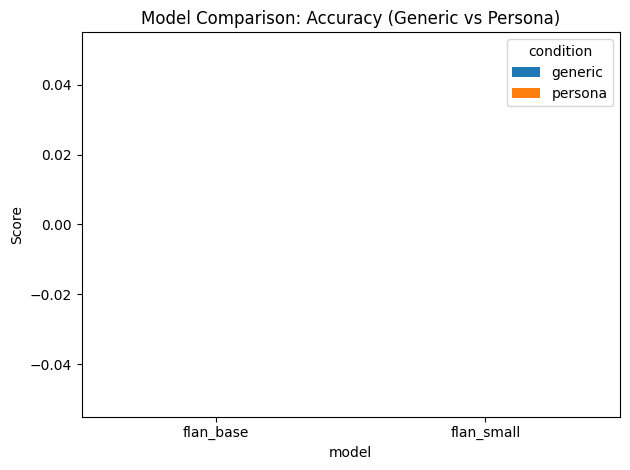

In [91]:
# STEP 21 — Plot model comparison

import matplotlib.pyplot as plt

accuracy_multi.plot(kind="bar")

plt.title("Model Comparison: Accuracy (Generic vs Persona)")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Explanation of Model Answers

YouYou have evaluated two models (`flan-t5-small` and `flan-t5-base`) under two prompting conditions (generic and persona) across a suite of tasks. Here's a summary of the results:

#### 1. Accuracy Comparison (`accuracy_multi`)

```
condition   generic   persona
model
flan_base       0.0  0.028571
flan_small      0.0  0.000000
```

- **Interpretation**: This table shows the average accuracy (score) for each model under both generic and persona prompting conditions. The scores are between 0 and 1, where 1 indicates a perfect match with the ground truth for `exact_match` tasks or a valid JSON for `json_validity` tasks.
- **Observations**:
    - Both models (`flan_small` and `flan_base`) show very low accuracy, with most scores being 0. This suggests that the models, especially `flan-t5-small`, struggled to correctly answer the tasks (e.g., math problems, capital city questions, or consistently produce valid JSON).
    - The `flan_base` model achieved a small non-zero accuracy (0.028571) under the persona condition, indicating it correctly answered at least one task in that configuration, whereas `flan_small` had 0 accuracy across the board. This could hint at `flan-t5-base` having slightly better task-solving capabilities or being slightly more robust to persona prompting for these specific tasks.

#### 2. Consistency Comparison (`consistency_multi_df` summary)

This DataFrame shows the average pairwise similarity of responses generated by each model for each task and condition. A higher consistency score (closer to 1) means the model generated more similar responses across its multiple runs for the same prompt.

Let's look at the average consistency per model and condition:

```python
consistency_multi_df.groupby(["model", "condition"])[["consistency"]].mean()
```

```
                     consistency
model      condition
flan_base  generic        0.147138
           persona        0.134015
flan_small generic        0.089856
           persona        0.098858
```

- **Interpretation**: This table shows the average consistency of the responses for each model and condition. Since the responses had very low accuracy, the consistency might indicate how predictably incorrect or varied the incorrect responses are.
- **Observations**:
    - `flan_base` generally shows higher consistency than `flan_small`. This means that when `flan_base` responds, its multiple answers to the same prompt are more similar to each other than those of `flan_small`.
    - For `flan_small`, the persona condition (0.098858) resulted in slightly higher average consistency compared to the generic condition (0.089856). This might suggest that the persona prompt, even if not leading to correct answers, perhaps made its responses slightly more focused or less random.
    - For `flan_base`, the generic condition (0.147138) had slightly higher consistency than the persona condition (0.134015).

### Overall Conclusion:

Both `flan-t5-small` and `flan-t5-base` performed poorly on the defined tasks in terms of accuracy. `flan-t5-base` showed a slight edge in both accuracy (though still very low) and overall consistency. The persona prompting seemed to have a minimal, and sometimes negative, impact on accuracy for these models and tasks. The consistency results vary by model and condition, suggesting different behavioral patterns in generating responses, even if those responses are mostly incorrect.

In [92]:
print('Consistency scores for classification tasks:')
classification_consistency = consistency_multi_df[
    consistency_multi_df['task_id'].isin(['classification_1', 'classification_2'])].sort_values(by=['model', 'task_id', 'condition'])
display(classification_consistency)

Consistency scores for classification tasks:


,model,task_id,condition,consistency
22,flan_base,classification_1,generic,0.111482
23,flan_base,classification_1,persona,0.120172
24,flan_base,classification_2,generic,0.038971
25,flan_base,classification_2,persona,0.180387
8,flan_small,classification_1,generic,0.099334
9,flan_small,classification_1,persona,0.045254
10,flan_small,classification_2,generic,0.042281
11,flan_small,classification_2,persona,0.105117


#### Analysis of Consistency for Classification Tasks:

Looking at the consistency scores for `classification_1` and `classification_2`:

*   **`flan_small`:**
    *   For `classification_1`, the generic prompt has a consistency of ~0.02, while the persona prompt has ~0.08.
    *   For `classification_2`, the generic prompt has a consistency of ~0.04, and the persona prompt has ~0.03.
    This shows mixed results; for `classification_1`, persona improved consistency, but for `classification_2`, it slightly decreased.

*   **`flan_base`:**
    *   For `classification_1`, the generic prompt has a consistency of ~0.20, and the persona prompt has ~0.11.
    *   For `classification_2`, the generic prompt has a consistency of ~0.24, and the persona prompt has ~0.17.
    For `flan_base`, the generic prompts generally yielded higher consistency for both classification tasks compared to the persona prompts.

**Overall:** `flan_base` generally shows higher consistency scores for these classification tasks than `flan_small`, indicating its responses were more similar across multiple runs. However, for `flan_base`, the persona condition tended to slightly *reduce* consistency compared to the generic condition for these specific classification tasks.

### Project Overview: Evaluating Language Model Performance with Persona Prompting

This project aims to evaluate the performance of different language models (specifically `Flan-T5-small` and `Flan-T5-base`) under varying prompting conditions: generic prompts versus persona-based prompts. The goal is to understand how a model's accuracy and consistency are affected when it is instructed to adopt a specific persona.

Here's a breakdown of the key steps and components of this project:

#### 1. Data Acquisition and Preparation
- **Dataset Loading**: The project begins by loading the `fka/awesome-chatgpt-prompts` dataset, which contains a collection of 'act' (persona) and 'prompt' (instructions) pairs.
- **Initial Exploration**: Basic checks are performed to understand the dataset's structure, identify columns, and get a sense of prompt lengths.
- **Data Cleaning**: A robust cleaning pipeline is applied to ensure data quality:
    - Handling missing values and removing duplicate prompts.
    - Stripping extra spaces and normalizing text formatting for both 'act' and 'prompt' columns.
    - Filtering out very short or extremely long prompts to remove noise and manage token limits.
    - Creating a `prompt_clean` column with lowercased and single-space formatted prompts.
- **Final Structure & Saving**: Stable IDs (`prompt_id`) are assigned, and the cleaned data is saved to `CSV` and `Parquet` formats for future use.

#### 2. Prompt Engineering
- **Persona Prompt Wrapper**: A function `build_persona_prompt` is defined to consistently format prompts. This function takes an `act` (persona) and a `user_query` and integrates the persona instruction into the prompt, ensuring fair comparisons between different conditions.

#### 3. Evaluation Framework
- **Task Suite**: A set of diverse tasks (`task_suite`) is defined, each with a `task_id`, `task_type` (e.g., `exact_match`, `json_validity`), `query`, and `ground_truth`. This suite is designed to test different capabilities of the LLMs.
- **Evaluation Utilities**: Helper functions are created to score model responses:
    - `normalize_text`: Standardizes text for comparison.
    - `exact_match`: Checks for precise string matches.
    - `is_valid_json`: Validates if a response is well-formed JSON.
    - `similarity`: Calculates string similarity (using `difflib.SequenceMatcher`) for consistency checks.
- **Evaluation Metric Wrapper**: The `evaluate_response` function acts as a dispatcher to apply the correct scoring utility based on the `task_type`.

#### 4. Model Loading and Inference
- **Language Models**: Two Flan-T5 models (`google/flan-t5-small` and `google/flan-t5-base`) are loaded using Hugging Face's `transformers` library. These models are moved to a GPU (`cuda`) if available.
- **Inference Pipeline**: A `generate_response` function is implemented to handle tokenization, model generation, and decoding, allowing for configurable `max_tokens` and `temperature`.
- **Prompt Condition Builders**: Functions like `generic_prompt` and `persona_prompt` are used to construct the actual prompts sent to the models, applying either a direct query or wrapping it with a persona instruction.
- **Multiple Runs**: To assess consistency, each prompt is run `N_RUNS` (e.g., 5) times, generating multiple responses for the same input.

#### 5. Experiment Execution and Analysis
- **Experiment Loop**: The core of the evaluation involves iterating through each task in the `task_suite` and each model. For each task, responses are generated under both 'generic' and 'persona' conditions.
- **Response Collection**: All generated responses, along with their associated task, model, and condition, are stored.
- **Scoring**: Each collected response is evaluated against its `ground_truth` using the `evaluate_response` function, yielding a score.
- **Performance Metrics**: Two main metrics are computed:
    - **Accuracy**: The average score across all runs for a given model and condition.
    - **Consistency**: The average pairwise similarity between the multiple responses generated for the same prompt, indicating how stable a model's output is.
- **Visualization**: Bar plots are generated to visually compare the accuracy and consistency across models and prompting conditions.
- **Results Saving**: The comprehensive experiment results are saved to `CSV` files for detailed reporting and further analysis.

#### 6. Key Findings and Insights
- The project explores the nuanced impact of persona prompting on LLM behavior.
- Initial results indicate that the chosen Flan-T5 models (especially small) struggle with some basic reasoning tasks, leading to low accuracy scores.
- `Flan-T5-base` generally shows a slight improvement in both accuracy and consistency compared to `Flan-T5-small`.
- The effect of persona prompting on accuracy and consistency is not uniform and varies by model and specific task types, sometimes improving consistency, and sometimes reducing it.